# Universidade Federal do Rio Grande do Norte
## Departamento de Engenharia da Computação e Automação
## DCA 3606 - Inteligancia Artificial
## RetinAI - Diagnostico de Retinopatia Diabética usando Inteligencia Artificial

Alunos:

1. Carlos Gabriel Medeiros da Silva
2. Daniel Bruno Trindade da Silva
3. Joanderson Luan da Silva Linhares
4. Maria Clara Moura de Freitas





# Imports (Bibliotecas) e configuração de acesso ao Driver

In [ ]:
!pip install protobuf==3.20.3

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2 # Usaremos um modelo pré-treinado (Transfer Learning)
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

2025-12-15 05:39:06.896724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765777147.090922      92 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765777147.141258      92 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import tensorflow as tf
print("Versão do TensorFlow:", tf.__version__)

# Verifica se a GPU foi detectada
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Sucesso! GPU detectada: {gpus}")
else:
    print("Atenção: O TensorFlow está rodando, mas NÃO detectou a GPU.")

Versão do TensorFlow: 2.18.0
Sucesso! GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [7]:
# CAMINHO PARA AS PASTAS COM O DATASET
base_dir = '/kaggle/input/retinopatia-dataset-reduzido/dataset_retinopatia_reduzido'

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

In [8]:
# Função para contar imagens em um diretório
def count_images(directory):
    count = 0
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                count += 1
    return count

# Contar imagens nos diretórios de treinamento, validação e teste
train_count = count_images(train_dir)
validation_count = count_images(validation_dir)
test_count = count_images(test_dir)

# Imprimir os resultados
print("Confirmando quantidade de imagens em cada diretório...")
print(f"Número de imagens no diretório de treinamento: {train_count}")
print(f"Número de imagens no diretório de validação: {validation_count}")
print(f"Número de imagens no diretório de teste: {test_count}")

Confirmando quantidade de imagens em cada diretório...
Número de imagens no diretório de treinamento: 2560
Número de imagens no diretório de validação: 727
Número de imagens no diretório de teste: 375


# Definição de Parametros

In [10]:
IMG_SIZE = (224, 224) # Tamanho padrão para muitos modelos pré-treinados
BATCH_SIZE = 64      # Quantas imagens processar de cada vez

# Data Augmentation
Utilizamos Data augmentation para aumentar o numero de imagens aplicando
- Rotação: Gira a imagem em alguns graus.
- Zoom: Aplica um zoom para dentro ou para fora.
- Flip Horizontal: Espelha a imagem (no seu caso, um olho espelhado ainda é um olho válido).
- Mudança de Brilho/Contraste: Simula diferentes condições de iluminação.
- Translação (Shift): Move a imagem um pouco para os lados ou para cima/baixo.

In [11]:
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"Classe '{class_name}': {num_images} imagens")

Classe 'negativo': 1253 imagens
Classe 'positivo': 1307 imagens


In [12]:
# 1. Gerador para dados de Treinamento (com Data Augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normaliza os pixels de 0-255 para 0-1
    rotation_range=20,       # Gira a imagem aleatoriamente
    width_shift_range=0.1,   # Desloca a largura
    height_shift_range=0.1,  # Desloca a altura
    shear_range=0.1,         # "Estica" a imagem
    zoom_range=0.1,          # Dá zoom aleatório
    horizontal_flip=True,    # Inverte horizontalmente
    fill_mode='nearest'
)

# 2. Gerador para dados de Validação e Teste (APENAS normalização)
# Nunca aplicamos augmentation nos dados de validação ou teste!
test_val_datagen = ImageDataGenerator(rescale=1./255)

# 3. Criar os "pipelines" que leem as imagens das pastas
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary' # Perfeito para diagnósticos Positivo/Negativo
)

validation_generator = test_val_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Não precisa embaralhar a validação
)

test_generator = test_val_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # Não precisa embaralhar o teste
)

# Verifique as classes (o Keras as infere dos nomes das subpastas)
print(f"Classes identificadas: {train_generator.class_indices}")

Found 2560 images belonging to 2 classes.
Found 727 images belonging to 2 classes.
Found 375 images belonging to 2 classes.
Classes identificadas: {'negativo': 0, 'positivo': 1}


# Configurando modelo


In [14]:
#EARLY STOP

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 1. EarlyStopping: Para o treino se não melhorar após 10 épocas
# monitor='val_auc' é melhor que 'val_loss' para dados médicos desbalanceados
early_stop = EarlyStopping(
    monitor='val_auc',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

# 2. ModelCheckpoint: Salva o melhor modelo durante o treino
# Salva no Drive para você não perder se o Colab desconectar
checkpoint_path = '/kaggle/working/melhor_retinAI.keras'

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_auc',
    save_best_only=True,
    mode='max', # Queremos o MÁXIMO de AUC
    verbose=1
)

# Redução de Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_auc', 
    factor=0.5,       # Reduz pela metade
    patience=5,       # Se ficar 5 épocas sem melhorar
    min_lr=1e-6,      # Limite mínimo
    verbose=1
)

# Lista de callbacks a serem usados
my_callbacks = [early_stop, checkpoint, reduce_lr]

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

# Definir o formato de entrada (Mantendo o seu padrão 224)
input_shape = (224, 224, 3) 

model = Sequential([
    Input(shape=input_shape),

    # --- Bloco 1 ---
    # PyTorch: self.conv1 = nn.Conv2d(Cin, 8, kernel_size=3)
    Conv2D(8, (3, 3), activation='relu'), 
    MaxPooling2D((2, 2)),

    # --- Bloco 2 ---
    # PyTorch: self.conv2 = nn.Conv2d(8, 16, kernel_size=3)
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # --- Bloco 3 ---
    # PyTorch: self.conv3 = nn.Conv2d(16, 32, kernel_size=3)
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # --- Bloco 4 ---
    # PyTorch: self.conv4 = nn.Conv2d(32, 64, kernel_size=3)
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # --- Classificador ---
    Flatten(), # Transforma o volume 3D em vetor 1D

    # PyTorch: self.fc1 = nn.Linear(self.num_flatten, 100)
    Dense(256, activation='relu'),
    
    # PyTorch: self.dropout_rate = 0.15
    Dropout(0.30), 

    # Saída
    # O original usava 2 neurônios (softmax), mas para seu código binary_crossentropy
    # usamos 1 neurônio (sigmoid).
    Dense(1, activation='sigmoid') 
])

# Compilação (Mantendo a mesma do seu notebook original)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', 'AUC'])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 222, 222, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 111, 111, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 109, 109, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 54, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 52, 52, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 26, 26, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,384,337 (9.10 MB)

 Trainable params: 2,384,337 (9.10 MB)

 Non-trainable params: 0 (0.00 B)

# Compilação e Treino



In [30]:
from tensorflow.keras.optimizers import Adam

# Métricas úteis para problemas médicos (desbalanceados ou não)
METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall'),
    tf.keras.metrics.AUC(name='auc') # Área sob a curva ROC
]

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=METRICS
)

In [31]:
#Parametros para treino:
EPOCHS = 50

steps_per_epoch = train_generator.n // BATCH_SIZE
validation_steps = validation_generator.n // BATCH_SIZE

In [32]:
from sklearn.utils import class_weight
import numpy as np

# Calcular pesos
train_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes),
    y=train_classes
)
class_weights_dict = dict(enumerate(class_weights))

#manual_weights = {0: 1.0, 1: 4.0}

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=my_callbacks,
    #class_weight=manual_weights
    class_weight=class_weights_dict #PESOS
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.5394 - auc: 0.6019 - loss: 0.6822 - precision: 0.5926 - recall: 0.3951
Epoch 1: val_auc did not improve from 0.95503
40/40 ━━━━━━━━━━━━━━━━━━━━ 42s 885ms/step - accuracy: 0.5405 - auc: 0.6040 - loss: 0.6818 - precision: 0.5940 - recall: 0.3953 - val_accuracy: 0.8196 - val_auc: 0.9101 - val_loss: 0.5912 - val_precision: 0.8601 - val_recall: 0.7456 - learning_rate: 1.0000e-04
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.7965 - auc: 0.8525 - loss: 0.5883 - precision: 0.7911 - recall: 0.8203
Epoch 2: val_auc did not improve from 0.95503
40/40 ━━━━━━━━━━━━━━━━━━━━ 33s 817ms/step - accuracy: 0.7968 - auc: 0.8527 - loss: 0.5873 - precision: 0.7913 - recall: 0.8207 - val_accuracy: 0.8665 - val_auc: 0.9180 - val_loss: 0.3892 - val_precision: 0.8567 - val_recall: 0.8669 - learning_rate: 1.0000e-04
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 752ms/step - accuracy: 0.8295 - auc: 0.8794 - loss: 0.4384 - precision: 0

# Avaliação e Analise do Modelo


### Grafico de evolução do Treinamento

Analise:
- Ideal: As curvas de treino e validação descem (perda) ou sobem (acurácia) juntas.

- Overfitting: A acurácia de treino sobe, mas a de validação para ou cai. Isso significa que o modelo decorou o treino e não aprendeu a generalizar.

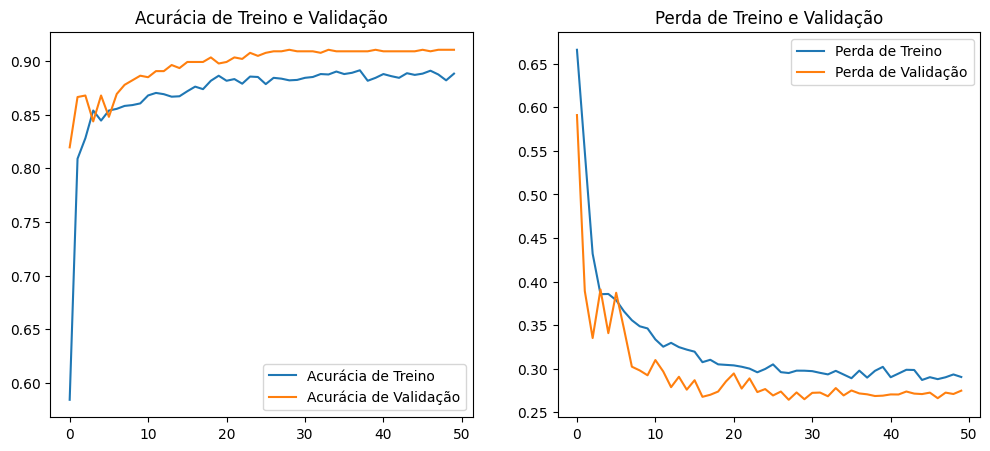

In [34]:
# Função para plotar os resultados
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Acurácia de Treino')
    plt.plot(epochs_range, val_acc, label='Acurácia de Validação')
    plt.legend(loc='lower right')
    plt.title('Acurácia de Treino e Validação')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Perda de Treino')
    plt.plot(epochs_range, val_loss, label='Perda de Validação')
    plt.legend(loc='upper right')
    plt.title('Perda de Treino e Validação')

    plt.show()

plot_history(history)

### Avaliação no Conjunto de Teste

In [36]:
print("\n--- Avaliando no Conjunto de Teste ---")
results = model.evaluate(test_generator, steps=test_generator.n // BATCH_SIZE)

print(f"Perda (Loss) no Teste: {results[0]:.4f}")
print(f"Acurácia no Teste: {results[1]:.4f}")
print(f"Precisão no Teste: {results[2]:.4f}")
print(f"Recall no Teste: {results[3]:.4f}")
print(f"AUC no Teste: {results[4]:.4f}")


--- Avaliando no Conjunto de Teste ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - accuracy: 0.8738 - auc: 0.6482 - loss: 0.2181 - precision: 0.4307 - recall: 0.6104         
Perda (Loss) no Teste: 0.2601
Acurácia no Teste: 0.8813
Precisão no Teste: 0.8333
Recall no Teste: 0.8955
AUC no Teste: 0.9635


### Matriz de Confusão

- Verdadeiros Positivos (VP): Corretamente disse "positivo".
- Verdadeiros Negativos (VN): Corretamente disse "negativo".
- Falsos Positivos (FP): Erradamente disse "positivo" (Erro Tipo I).
- Falsos Negativos (FN): Erradamente disse "negativo" (Erro Tipo II) - Este é o mais perigoso em medicina!

6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 406ms/step


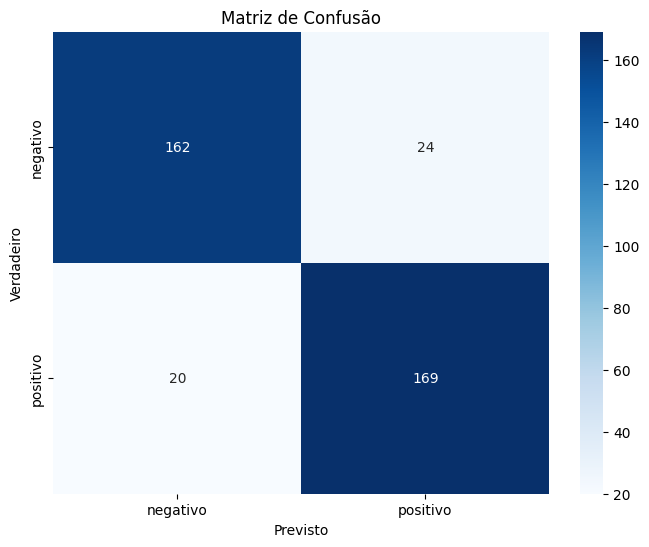


--- Relatório de Classificação ---
              precision    recall  f1-score   support

    negativo       0.89      0.87      0.88       186
    positivo       0.88      0.89      0.88       189

    accuracy                           0.88       375
   macro avg       0.88      0.88      0.88       375
weighted avg       0.88      0.88      0.88       375



In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# 1. Obter as previsões do modelo
# (Precisamos resetar o gerador de teste)
test_generator.reset()
predictions = model.predict(test_generator, steps=test_generator.n // BATCH_SIZE + 1)
# As saídas do sigmoid são probabilidades (0.0 a 1.0). Convertemos para 0 ou 1.
predicted_classes = (predictions > 0.5).astype(int).flatten()

# 2. Obter os rótulos verdadeiros
true_classes = test_generator.classes
# Precisamos garantir que estamos comparando o número certo de amostras
true_classes = true_classes[:len(predicted_classes)]

# 3. Calcular a Matriz de Confusão
cm = confusion_matrix(true_classes, predicted_classes)

# 4. Plotar a Matriz
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_generator.class_indices.keys(),
            yticklabels=test_generator.class_indices.keys())
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.title('Matriz de Confusão')
plt.show()

# 5. Relatório de Classificação
print("\n--- Relatório de Classificação ---")
print(classification_report(true_classes, predicted_classes,
                            target_names=test_generator.class_indices.keys()))

# Salvando Modelo

In [ ]:
CAMINHO_MODELO = '/kaggle/working/meu_modelo.keras' 

# Salva o modelo
print(f"Salvando o modelo em: {CAMINHO_MODELO}")
model.save(CAMINHO_MODELO)
print("Modelo salvo com sucesso!")